# Quantile Regression Rolling Backtest

This notebook rebuilds the quantile workflow around a **coverage-first rolling backtest** for the same four representative series used elsewhere in the project:

- Longest History
- Highest Total Weight
- Most Volatile
- Most Stable

## What changed

- no more single 80/20 split
- use expanding chronological folds with separate **train / calibration / validation**
- select the interval recipe **per fold** using weighted calibration coverage first, width second
- report final metrics only from **stitched out-of-sample validation predictions**

## Important note about `test.parquet`

`test.parquet` still has **no `y_target`**, so it remains **audit-only** here.

In [1]:
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.dataset as ds
import pyarrow.parquet as pq
import lightgbm as lgb
from IPython.display import Markdown, display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130

ROOT = Path.cwd()
TRAIN_PATH = ROOT / "data" / "ts-forecasting" / "train.parquet"
TEST_PATH = ROOT / "data" / "ts-forecasting" / "test.parquet"
OUTPUT_DIR = ROOT / "data" / "quantile_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SERIES_KEYS = ["code", "sub_code", "sub_category", "horizon"]
TIME_COL = "ts_index"
TARGET_COL = "y_target"
WEIGHT_COL = "weight"
REASON_ORDER = [
    "Longest History",
    "Highest Total Weight",
    "Most Volatile",
    "Most Stable",
]
MIN_TRAIN_LEN = 70
CALIBRATION_LEN = 20
VALIDATION_LEN = 20
LAGS = 10
ROLLING_WINDOW = 5
SEED = 42
NOMINAL_COVERAGE = 0.80
QUANTILE_GRID = [0.02, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.98]

FEATURE_COLS = [name for name in pq.ParquetFile(TRAIN_PATH).schema.names if name.startswith("feature_")]

print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Output directory: {OUTPUT_DIR}")

Feature columns: 86
Output directory: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs


In [2]:
train_meta = pd.read_parquet(
    TRAIN_PATH,
    columns=[*SERIES_KEYS, TIME_COL, TARGET_COL, WEIGHT_COL],
)
test_meta = pd.read_parquet(
    TEST_PATH,
    columns=[*SERIES_KEYS, TIME_COL],
)

assert TARGET_COL not in test_meta.columns, "test.parquet unexpectedly contains y_target"

series_stats = (
    train_meta.groupby(SERIES_KEYS)
    .agg(
        length=(TIME_COL, "size"),
        start=(TIME_COL, "min"),
        end=(TIME_COL, "max"),
        total_weight=(WEIGHT_COL, "sum"),
        target_std=(TARGET_COL, "std"),
    )
    .reset_index()
)
series_stats["crosses_cutoff"] = (series_stats["start"] <= 2880) & (series_stats["end"] > 2880)

eligible = series_stats[(series_stats["crosses_cutoff"]) & (series_stats["length"] >= 120)].copy()
eligible["target_std"] = eligible["target_std"].fillna(0.0)
stable_pool = eligible[eligible["target_std"] > 0].copy()

chosen = pd.concat(
    [
        eligible.nlargest(1, "length").assign(reason="Longest History"),
        eligible.nlargest(1, "total_weight").assign(reason="Highest Total Weight"),
        eligible.nlargest(1, "target_std").assign(reason="Most Volatile"),
        stable_pool.nsmallest(1, "target_std").assign(reason="Most Stable"),
    ],
    ignore_index=True,
).drop_duplicates(subset=SERIES_KEYS)

chosen["reason"] = pd.Categorical(chosen["reason"], categories=REASON_ORDER, ordered=True)
chosen = chosen.sort_values("reason").reset_index(drop=True)
chosen["series_id"] = chosen.apply(
    lambda row: "__".join(
        [str(row["code"]), str(row["sub_code"]), str(row["sub_category"]), str(row["horizon"])]
    ),
    axis=1,
)

exact_test_keys = test_meta[SERIES_KEYS].drop_duplicates()
signature_counts = (
    test_meta.groupby(["sub_category", "horizon"])
    .size()
    .reset_index(name="test_rows_same_subcategory_horizon")
)

test_audit = (
    chosen.merge(exact_test_keys.assign(exact_series_in_test=True), on=SERIES_KEYS, how="left")
    .merge(signature_counts, on=["sub_category", "horizon"], how="left")
    .loc[:, ["reason", "series_id", "exact_series_in_test", "test_rows_same_subcategory_horizon"]]
    .fillna({"exact_series_in_test": False, "test_rows_same_subcategory_horizon": 0})
)
test_audit["exact_series_in_test"] = test_audit["exact_series_in_test"].astype(bool)
test_audit["test_rows_same_subcategory_horizon"] = test_audit["test_rows_same_subcategory_horizon"].astype(int)
test_audit_path = OUTPUT_DIR / "quantile_test_audit.csv"
test_audit.to_csv(test_audit_path, index=False)

display(Markdown("## Chosen series"))
display(
    chosen[
        [*SERIES_KEYS, "series_id", "reason", "length", "start", "end", "target_std", "total_weight"]
    ].round({"target_std": 4, "total_weight": 4})
)

display(Markdown("## Test-set audit"))
display(test_audit)
print("Saved:", test_audit_path)

## Chosen series

,code,sub_code,sub_category,horizon,series_id,reason,length,start,end,target_std,total_weight
0,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,X9BZ68VQ__OYJGNSQK__DPPUO5X2__1,Longest History,212,2826,3037,2.6416,9.060035e+02
1,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,SJZP0OVU__OYJGNSQK__NQ58FVQM__25,Highest Total Weight,156,2874,3032,0.0004,4.349747e+10
2,W4S29LF4,KL66VIS3,PHHHVYZI,25,W4S29LF4__KL66VIS3__PHHHVYZI__25,Most Volatile,162,2747,2911,296.7600,4.563000e-01
3,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,SJZP0OVU__OYJGNSQK__NQ58FVQM__1,Most Stable,170,2874,3052,0.0001,3.869062e+10


## Test-set audit

,reason,series_id,exact_series_in_test,test_rows_same_subcategory_horizon
0,Longest History,X9BZ68VQ__OYJGNSQK__DPPUO5X2__1,False,76292
1,Highest Total Weight,SJZP0OVU__OYJGNSQK__NQ58FVQM__25,False,65741
2,Most Volatile,W4S29LF4__KL66VIS3__PHHHVYZI__25,False,65741
3,Most Stable,SJZP0OVU__OYJGNSQK__NQ58FVQM__1,False,75887


Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_test_audit.csv


In [3]:
def build_exact_filter(frame: pd.DataFrame):
    expr = None
    for row in frame.itertuples(index=False):
        cond = (
            (ds.field("code") == row.code)
            & (ds.field("sub_code") == row.sub_code)
            & (ds.field("sub_category") == row.sub_category)
            & (ds.field("horizon") == row.horizon)
        )
        expr = cond if expr is None else expr | cond
    return expr


def read_exact_series(path: Path, include_target: bool = True, include_weight: bool = True) -> pd.DataFrame:
    cols = [*SERIES_KEYS, TIME_COL, *FEATURE_COLS]
    if include_target:
        cols.append(TARGET_COL)
    if include_weight:
        cols.append(WEIGHT_COL)
    dataset = ds.dataset(path, format="parquet")
    table = dataset.to_table(columns=cols, filter=build_exact_filter(chosen[SERIES_KEYS]))
    return table.to_pandas()


chosen_train = read_exact_series(TRAIN_PATH, include_target=True, include_weight=True)
chosen_train = chosen_train.sort_values(SERIES_KEYS + [TIME_COL]).reset_index(drop=True)

print("Chosen-train rows:", len(chosen_train))


def _clip01(x: float) -> float:
    return float(np.minimum(np.maximum(x, 0.0), 1.0))


def pair_label(lower_q: float, upper_q: float) -> str:
    return f"q{int(round(lower_q * 100)):02d}-q{int(round(upper_q * 100)):02d}"


def weighted_rmse_score(y_true, y_pred, weights) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)
    denom = np.sum(weights * y_true**2)
    if denom <= 0:
        return 0.0
    ratio = np.sum(weights * (y_true - y_pred) ** 2) / denom
    return float(np.sqrt(1.0 - _clip01(ratio)))


def point_metrics(y_true, y_pred, weights) -> dict[str, float]:
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
        "Skill": weighted_rmse_score(y_true, y_pred, weights),
    }


def _norm_weights(weights):
    if weights is None:
        return None
    weights = np.asarray(weights, dtype=float)
    total = weights.sum()
    if total <= 0:
        return np.ones_like(weights) / len(weights)
    return weights / total


def picp(y_true, lower, upper, weights=None) -> float:
    inside = ((np.asarray(y_true) >= np.asarray(lower)) & (np.asarray(y_true) <= np.asarray(upper))).astype(float)
    return float(np.average(inside, weights=_norm_weights(weights)))


def mpiw(lower, upper, weights=None) -> float:
    width = np.asarray(upper, dtype=float) - np.asarray(lower, dtype=float)
    return float(np.average(width, weights=_norm_weights(weights)))


def nmpiw(y_true, lower, upper, weights=None) -> float:
    y_true = np.asarray(y_true, dtype=float)
    target_range = float(np.max(y_true) - np.min(y_true))
    return float(mpiw(lower, upper, weights) / (target_range + 1e-12))


def winkler_score(y_true, lower, upper, alpha: float, weights=None) -> float:
    y_true = np.asarray(y_true, dtype=float)
    lower = np.asarray(lower, dtype=float)
    upper = np.asarray(upper, dtype=float)
    score = (
        (upper - lower)
        + (2.0 / alpha) * np.maximum(lower - y_true, 0.0)
        + (2.0 / alpha) * np.maximum(y_true - upper, 0.0)
    )
    return float(np.average(score, weights=_norm_weights(weights)))


def weighted_quantile(values, quantile, sample_weight):
    values = np.asarray(values, dtype=float)
    sample_weight = np.asarray(sample_weight, dtype=float)
    if len(values) == 0:
        raise ValueError("weighted_quantile requires at least one value")
    order = np.argsort(values)
    values = values[order]
    sample_weight = sample_weight[order]
    cdf = np.cumsum(sample_weight) / sample_weight.sum()
    idx = min(np.searchsorted(cdf, quantile, side="left"), len(values) - 1)
    return float(values[idx])


def finite_sample_coverage_target(calibration_len: int, nominal_coverage: float) -> float:
    # Small 20-point calibration folds need a conservative coverage buffer.
    if calibration_len <= 0:
        raise ValueError("calibration_len must be positive")
    rank = int(np.ceil((calibration_len + 1) * nominal_coverage))
    rank = min(max(rank, 1), calibration_len)
    conservative_target = float(rank / calibration_len)
    return max(nominal_coverage, conservative_target - 0.01)


def normalize_training_weights(weights):
    weights = np.asarray(weights, dtype=float)
    positive = weights[weights > 0]
    if len(positive) == 0:
        return np.ones_like(weights)
    return weights / positive.mean()


def prepare_series_frame(series_df: pd.DataFrame):
    frame = series_df.sort_values(TIME_COL).reset_index(drop=True).copy()
    for lag in range(1, LAGS + 1):
        frame[f"lag_{lag}"] = frame[TARGET_COL].shift(lag)

    history = frame[TARGET_COL].shift(1)
    frame["roll_mean_5"] = history.rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).mean()
    frame["roll_std_5"] = history.rolling(ROLLING_WINDOW, min_periods=ROLLING_WINDOW).std()

    model_cols = [*FEATURE_COLS, *[f"lag_{lag}" for lag in range(1, LAGS + 1)], "roll_mean_5", "roll_std_5"]
    frame = frame.dropna(
        subset=[*[f"lag_{lag}" for lag in range(1, LAGS + 1)], "roll_mean_5", "roll_std_5"]
    ).reset_index(drop=True)
    return frame, model_cols


def rolling_folds(frame: pd.DataFrame):
    folds = []
    train_end = MIN_TRAIN_LEN
    fold_id = 1
    while train_end + CALIBRATION_LEN + VALIDATION_LEN <= len(frame):
        calibration_end = train_end + CALIBRATION_LEN
        validation_end = calibration_end + VALIDATION_LEN
        folds.append(
            (
                fold_id,
                frame.iloc[:train_end].copy(),
                frame.iloc[train_end:calibration_end].copy(),
                frame.iloc[calibration_end:validation_end].copy(),
            )
        )
        train_end += VALIDATION_LEN
        fold_id += 1
    return folds


def train_quantile_model(X, y, sample_weight, alpha: float):
    model = lgb.LGBMRegressor(
        objective="quantile",
        alpha=alpha,
        n_estimators=400,
        learning_rate=0.04,
        max_depth=5,
        num_leaves=31,
        min_child_samples=10,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=SEED,
        verbosity=-1,
    )
    model.fit(X, y, sample_weight=sample_weight)
    return model


def enforce_monotonic_matrix(matrix):
    return np.sort(np.asarray(matrix, dtype=float), axis=1)


def evaluate_interval(y_true, lower, upper, weights):
    return {
        "wPICP_80": picp(y_true, lower, upper, weights),
        "PICP_80": picp(y_true, lower, upper),
        "wMPIW_80": mpiw(lower, upper, weights),
        "MPIW_80": mpiw(lower, upper),
        "wNMPIW_80": nmpiw(y_true, lower, upper, weights),
        "NMPIW_80": nmpiw(y_true, lower, upper),
        "Winkler_80": winkler_score(
            y_true, lower, upper, alpha=1.0 - NOMINAL_COVERAGE, weights=weights
        ),
    }


def select_best_pair(y_true, weights, pred_matrix, quantiles, selection_target):
    candidate_rows = []
    for i, q_low in enumerate(quantiles):
        if q_low >= 0.50:
            continue
        for j, q_high in enumerate(quantiles):
            if q_high <= 0.50 or q_high <= q_low:
                continue
            lower = pred_matrix[:, i]
            upper = pred_matrix[:, j]
            metrics = evaluate_interval(y_true, lower, upper, weights)
            candidate_rows.append(
                {
                    "selected_lower_quantile": float(q_low),
                    "selected_upper_quantile": float(q_high),
                    "selected_interval_pair": pair_label(q_low, q_high),
                    **metrics,
                }
            )

    candidate_df = pd.DataFrame(candidate_rows)
    good = candidate_df[candidate_df["wPICP_80"] >= selection_target].copy()
    if not good.empty:
        good = good.sort_values(
            ["wMPIW_80", "Winkler_80", "selected_lower_quantile", "selected_upper_quantile"]
        ).reset_index(drop=True)
        return good.iloc[0].to_dict(), candidate_df

    candidate_df = candidate_df.sort_values(
        ["wPICP_80", "Winkler_80", "wMPIW_80"],
        ascending=[False, True, True],
    ).reset_index(drop=True)
    return candidate_df.iloc[0].to_dict(), candidate_df


def make_candidate(
    method,
    y_cal,
    w_cal,
    cal_lower,
    cal_median,
    cal_upper,
    y_val,
    w_val,
    val_lower,
    val_median,
    val_upper,
    lower_q,
    upper_q,
    selection_target,
    extra=None,
):
    cal_metrics = evaluate_interval(y_cal, cal_lower, cal_upper, w_cal)
    val_metrics = evaluate_interval(y_val, val_lower, val_upper, w_val)
    row = {
        "method": method,
        "selected_lower_quantile": float(lower_q),
        "selected_upper_quantile": float(upper_q),
        "selected_interval_pair": pair_label(lower_q, upper_q),
        **{f"cal_{key}": value for key, value in cal_metrics.items()},
        **point_metrics(y_val, val_median, w_val),
        **val_metrics,
        "selection_target": float(selection_target),
        "calibration_target_hit": bool(cal_metrics["wPICP_80"] >= selection_target),
    }
    if extra:
        row.update(extra)
    return row


def summarize_predictions(pred_df: pd.DataFrame, selected_fold_df: pd.DataFrame):
    rows = []
    for (series, series_id), group in pred_df.groupby(["Series", "Series ID"], sort=False):
        y = group[TARGET_COL].to_numpy(dtype=float)
        w = group[WEIGHT_COL].to_numpy(dtype=float)
        lower = group["pred_lower"].to_numpy(dtype=float)
        median = group["pred_median"].to_numpy(dtype=float)
        upper = group["pred_upper"].to_numpy(dtype=float)
        fold_meta = selected_fold_df[selected_fold_df["Series"] == series][
            ["fold_id", "method", "selected_interval_pair"]
        ].drop_duplicates()
        row = {
            "Series": series,
            "Series ID": series_id,
            "fold_count": int(fold_meta["fold_id"].nunique()),
            **point_metrics(y, median, w),
            **evaluate_interval(y, lower, upper, w),
            "dominant_method": fold_meta["method"].value_counts().idxmax(),
            "dominant_interval_pair": fold_meta["selected_interval_pair"].value_counts().idxmax(),
        }
        row["Coverage gap vs 0.80"] = row["wPICP_80"] - NOMINAL_COVERAGE
        row["needs_manual_review"] = not (0.75 <= row["wPICP_80"] <= 0.85)
        row["manual_review_reason"] = (
            f"wPICP_80={row['wPICP_80']:.3f} outside [0.75, 0.85]"
            if row["needs_manual_review"]
            else ""
        )
        rows.append(row)

    summary_df = pd.DataFrame(rows)
    summary_df["Series"] = pd.Categorical(summary_df["Series"], categories=REASON_ORDER, ordered=True)
    return summary_df.sort_values("Series").reset_index(drop=True)


def assert_prediction_monotonic(pred_df: pd.DataFrame):
    assert pred_df["pred_lower"].le(pred_df["pred_median"]).all()
    assert pred_df["pred_median"].le(pred_df["pred_upper"]).all()


def assert_non_overlapping_validation(selected_fold_df: pd.DataFrame):
    for series, group in selected_fold_df.groupby("Series", sort=False):
        ordered = group.sort_values("validation_ts_start").reset_index(drop=True)
        assert ordered["fold_id"].nunique() >= 2, f"{series} has fewer than 2 folds"
        for idx in range(1, len(ordered)):
            prev_end = int(ordered.loc[idx - 1, "validation_ts_end"])
            curr_start = int(ordered.loc[idx, "validation_ts_start"])
            assert curr_start > prev_end, f"{series} has overlapping validation windows"

Chosen-train rows: 700


In [4]:
prepared_series = {}
fold_rows = []
prediction_rows = []

for meta in chosen.itertuples(index=False):
    mask = np.ones(len(chosen_train), dtype=bool)
    for key in SERIES_KEYS:
        mask &= chosen_train[key].eq(getattr(meta, key))

    raw_series = chosen_train.loc[mask].copy()
    prepared, model_cols = prepare_series_frame(raw_series)
    prepared_series[meta.reason] = prepared[[TIME_COL, TARGET_COL]].copy()

    folds = rolling_folds(prepared)
    if len(folds) < 2:
        raise RuntimeError(f"{meta.reason} has fewer than 2 folds after warmup")

    print(f"{meta.reason:<22} prepared={len(prepared):>4}  folds={len(folds):>2}")

    for fold_id, train_case, calibration_case, validation_case in folds:
        selection_target = finite_sample_coverage_target(len(calibration_case), NOMINAL_COVERAGE)
        X_train = train_case[model_cols]
        X_cal = calibration_case[model_cols]
        X_val = validation_case[model_cols]

        y_train = train_case[TARGET_COL].to_numpy(dtype=float)
        y_cal = calibration_case[TARGET_COL].to_numpy(dtype=float)
        y_val = validation_case[TARGET_COL].to_numpy(dtype=float)
        w_train = train_case[WEIGHT_COL].to_numpy(dtype=float)
        w_cal = calibration_case[WEIGHT_COL].to_numpy(dtype=float)
        w_val = validation_case[WEIGHT_COL].to_numpy(dtype=float)

        model_weight = normalize_training_weights(w_train)

        pred_cal_cols = []
        pred_val_cols = []
        for quantile in QUANTILE_GRID:
            model = train_quantile_model(X_train, y_train, model_weight, quantile)
            pred_cal_cols.append(model.predict(X_cal))
            pred_val_cols.append(model.predict(X_val))

        pred_cal_matrix = enforce_monotonic_matrix(np.column_stack(pred_cal_cols))
        pred_val_matrix = enforce_monotonic_matrix(np.column_stack(pred_val_cols))
        median_idx = QUANTILE_GRID.index(0.50)

        raw_choice, _ = select_best_pair(
            y_cal, w_cal, pred_cal_matrix, QUANTILE_GRID, selection_target
        )
        low_idx = QUANTILE_GRID.index(float(raw_choice["selected_lower_quantile"]))
        high_idx = QUANTILE_GRID.index(float(raw_choice["selected_upper_quantile"]))

        lgb_pair_row = make_candidate(
            "lgb_pair",
            y_cal,
            w_cal,
            pred_cal_matrix[:, low_idx],
            pred_cal_matrix[:, median_idx],
            pred_cal_matrix[:, high_idx],
            y_val,
            w_val,
            pred_val_matrix[:, low_idx],
            pred_val_matrix[:, median_idx],
            pred_val_matrix[:, high_idx],
            float(raw_choice["selected_lower_quantile"]),
            float(raw_choice["selected_upper_quantile"]),
            selection_target,
        )

        candidates = [lgb_pair_row]

        conformity = np.maximum.reduce(
            [
                pred_cal_matrix[:, low_idx] - y_cal,
                y_cal - pred_cal_matrix[:, high_idx],
                np.zeros_like(y_cal),
            ]
        )
        calibration_adjustment = weighted_quantile(conformity, selection_target, w_cal)
        lgb_conformal_row = make_candidate(
            "lgb_conformal",
            y_cal,
            w_cal,
            pred_cal_matrix[:, low_idx] - calibration_adjustment,
            pred_cal_matrix[:, median_idx],
            pred_cal_matrix[:, high_idx] + calibration_adjustment,
            y_val,
            w_val,
            pred_val_matrix[:, low_idx] - calibration_adjustment,
            pred_val_matrix[:, median_idx],
            pred_val_matrix[:, high_idx] + calibration_adjustment,
            float(raw_choice["selected_lower_quantile"]),
            float(raw_choice["selected_upper_quantile"]),
            selection_target,
            extra={"calibration_adjustment": float(calibration_adjustment)},
        )
        candidates.append(lgb_conformal_row)

        lag_cal = calibration_case["lag_1"].to_numpy(dtype=float)
        lag_val = validation_case["lag_1"].to_numpy(dtype=float)
        residuals = y_cal - lag_cal
        naive_cal_matrix = np.column_stack(
            [lag_cal + weighted_quantile(residuals, quantile, w_cal) for quantile in QUANTILE_GRID]
        )
        naive_val_matrix = np.column_stack(
            [lag_val + weighted_quantile(residuals, quantile, w_cal) for quantile in QUANTILE_GRID]
        )
        naive_cal_matrix = enforce_monotonic_matrix(naive_cal_matrix)
        naive_val_matrix = enforce_monotonic_matrix(naive_val_matrix)
        naive_choice, _ = select_best_pair(
            y_cal, w_cal, naive_cal_matrix, QUANTILE_GRID, selection_target
        )
        naive_low_idx = QUANTILE_GRID.index(float(naive_choice["selected_lower_quantile"]))
        naive_high_idx = QUANTILE_GRID.index(float(naive_choice["selected_upper_quantile"]))
        naive_row = make_candidate(
            "naive_lag1",
            y_cal,
            w_cal,
            naive_cal_matrix[:, naive_low_idx],
            naive_cal_matrix[:, median_idx],
            naive_cal_matrix[:, naive_high_idx],
            y_val,
            w_val,
            naive_val_matrix[:, naive_low_idx],
            naive_val_matrix[:, median_idx],
            naive_val_matrix[:, naive_high_idx],
            float(naive_choice["selected_lower_quantile"]),
            float(naive_choice["selected_upper_quantile"]),
            selection_target,
        )
        candidates.append(naive_row)

        candidate_df = pd.DataFrame(candidates)
        viable = candidate_df[candidate_df["cal_wPICP_80"] >= selection_target].copy()
        if not viable.empty:
            selected = viable.sort_values(["cal_wMPIW_80", "cal_Winkler_80", "method"]).iloc[0].to_dict()
        else:
            selected = candidate_df.sort_values(
                ["cal_wPICP_80", "cal_Winkler_80", "cal_wMPIW_80"],
                ascending=[False, True, True],
            ).iloc[0].to_dict()

        for candidate in candidates:
            candidate.update(
                {
                    "Series": meta.reason,
                    "Series ID": meta.series_id,
                    "fold_id": fold_id,
                    "train_len": len(train_case),
                    "calibration_len": len(calibration_case),
                    "validation_len": len(validation_case),
                    "train_ts_start": int(train_case[TIME_COL].min()),
                    "train_ts_end": int(train_case[TIME_COL].max()),
                    "calibration_ts_start": int(calibration_case[TIME_COL].min()),
                    "calibration_ts_end": int(calibration_case[TIME_COL].max()),
                    "validation_ts_start": int(validation_case[TIME_COL].min()),
                    "validation_ts_end": int(validation_case[TIME_COL].max()),
                    "is_selected": candidate["method"] == selected["method"],
                }
            )
            fold_rows.append(candidate)

        if selected["method"] == "lgb_pair":
            selected_lower = pred_val_matrix[:, low_idx]
            selected_median = pred_val_matrix[:, median_idx]
            selected_upper = pred_val_matrix[:, high_idx]
        elif selected["method"] == "lgb_conformal":
            selected_lower = pred_val_matrix[:, low_idx] - selected["calibration_adjustment"]
            selected_median = pred_val_matrix[:, median_idx]
            selected_upper = pred_val_matrix[:, high_idx] + selected["calibration_adjustment"]
        else:
            selected_lower = naive_val_matrix[:, naive_low_idx]
            selected_median = naive_val_matrix[:, median_idx]
            selected_upper = naive_val_matrix[:, naive_high_idx]

        for ts_value, y_value, weight_value, lower_value, median_value, upper_value in zip(
            validation_case[TIME_COL].to_numpy(dtype=int),
            y_val,
            w_val,
            selected_lower,
            selected_median,
            selected_upper,
        ):
            prediction_rows.append(
                {
                    "Series": meta.reason,
                    "Series ID": meta.series_id,
                    "fold_id": fold_id,
                    "method": selected["method"],
                    "selected_lower_quantile": float(selected["selected_lower_quantile"]),
                    "selected_upper_quantile": float(selected["selected_upper_quantile"]),
                    "selected_interval_pair": selected["selected_interval_pair"],
                    TIME_COL: int(ts_value),
                    TARGET_COL: float(y_value),
                    WEIGHT_COL: float(weight_value),
                    "pred_lower": float(lower_value),
                    "pred_median": float(median_value),
                    "pred_upper": float(upper_value),
                    "is_validation_row": True,
                }
            )

fold_df = pd.DataFrame(fold_rows)
prediction_df = pd.DataFrame(prediction_rows)
selected_fold_df = fold_df[fold_df["is_selected"]].copy().sort_values(["Series", "fold_id"]).reset_index(drop=True)

assert_prediction_monotonic(prediction_df)
assert prediction_df["is_validation_row"].all()
assert_non_overlapping_validation(selected_fold_df)

method_summary = (
    selected_fold_df.groupby(["Series", "method"], sort=False)
    .agg(selected_folds=("fold_id", "nunique"))
    .reset_index()
)
fold_counts = selected_fold_df.groupby("Series")["fold_id"].nunique().rename("fold_count")
method_summary = method_summary.merge(fold_counts, on="Series", how="left")
method_summary["selected_share"] = method_summary["selected_folds"] / method_summary["fold_count"]
method_summary["Series"] = pd.Categorical(method_summary["Series"], categories=REASON_ORDER, ordered=True)
method_summary = method_summary.sort_values(["Series", "selected_folds", "method"], ascending=[True, False, True]).reset_index(drop=True)

summary_df = summarize_predictions(prediction_df, selected_fold_df)
summary_check = summarize_predictions(prediction_df, selected_fold_df)

compare_cols = [
    "RMSE",
    "MAE",
    "R2",
    "Skill",
    "wPICP_80",
    "PICP_80",
    "wMPIW_80",
    "MPIW_80",
    "wNMPIW_80",
    "NMPIW_80",
    "Winkler_80",
    "Coverage gap vs 0.80",
]
for column in compare_cols:
    assert np.allclose(summary_df[column].to_numpy(dtype=float), summary_check[column].to_numpy(dtype=float))

fold_metrics_path = OUTPUT_DIR / "quantile_fold_metrics.csv"
method_summary_path = OUTPUT_DIR / "quantile_method_summary.csv"
predictions_path = OUTPUT_DIR / "quantile_validation_predictions.csv"
summary_path = OUTPUT_DIR / "quantile_metrics_summary.csv"

fold_df.to_csv(fold_metrics_path, index=False)
method_summary.to_csv(method_summary_path, index=False)
prediction_df.to_csv(predictions_path, index=False)
summary_df.to_csv(summary_path, index=False)

display(Markdown("## Aggregate out-of-sample summary"))
display(summary_df.round(4))

display(Markdown("## Selected-method counts"))
display(method_summary.round(4))

print("Saved:", fold_metrics_path)
print("Saved:", method_summary_path)
print("Saved:", predictions_path)
print("Saved:", summary_path)

Longest History        prepared= 202  folds= 5
Highest Total Weight   prepared= 146  folds= 2
Most Volatile          prepared= 152  folds= 3
Most Stable            prepared= 160  folds= 3


## Aggregate out-of-sample summary

,Series,Series ID,fold_count,RMSE,MAE,R2,Skill,wPICP_80,PICP_80,wMPIW_80,MPIW_80,wNMPIW_80,NMPIW_80,Winkler_80,dominant_method,dominant_interval_pair,Coverage gap vs 0.80,needs_manual_review,manual_review_reason
0,Longest History,X9BZ68VQ__OYJGNSQK__DPPUO5X2__1,5,3.5512,1.9549,-0.0588,0.0000,0.8622,0.8600,6.4367,6.4560,0.2181,0.2187,11.3426,lgb_conformal,q02-q95,0.0622,True,"wPICP_80=0.862 outside [0.75, 0.85]"
1,Highest Total Weight,SJZP0OVU__OYJGNSQK__NQ58FVQM__25,2,0.0003,0.0002,0.6733,0.8647,0.7924,0.8000,0.0005,0.0005,0.3707,0.3782,0.0010,naive_lag1,q05-q90,-0.0076,False,
2,Most Volatile,W4S29LF4__KL66VIS3__PHHHVYZI__25,3,61.1842,49.6347,0.8628,0.9592,0.7745,0.7667,159.0909,158.2188,0.3000,0.2984,243.3213,naive_lag1,q10-q95,-0.0255,False,
3,Most Stable,SJZP0OVU__OYJGNSQK__NQ58FVQM__1,3,0.0002,0.0001,-0.5381,0.0000,0.7618,0.7667,0.0004,0.0004,0.4850,0.4956,0.0006,lgb_conformal,q10-q90,-0.0382,False,


## Selected-method counts

,Series,method,selected_folds,fold_count,selected_share
0,Longest History,lgb_conformal,5,5,1.0000
1,Highest Total Weight,naive_lag1,2,2,1.0000
2,Most Volatile,naive_lag1,3,3,1.0000
3,Most Stable,lgb_conformal,2,3,0.6667
4,Most Stable,naive_lag1,1,3,0.3333


Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_fold_metrics.csv
Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_method_summary.csv
Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_validation_predictions.csv
Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_metrics_summary.csv


Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_longest_history_plot.png
Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_highest_total_weight_plot.png
Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_most_volatile_plot.png
Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_most_stable_plot.png


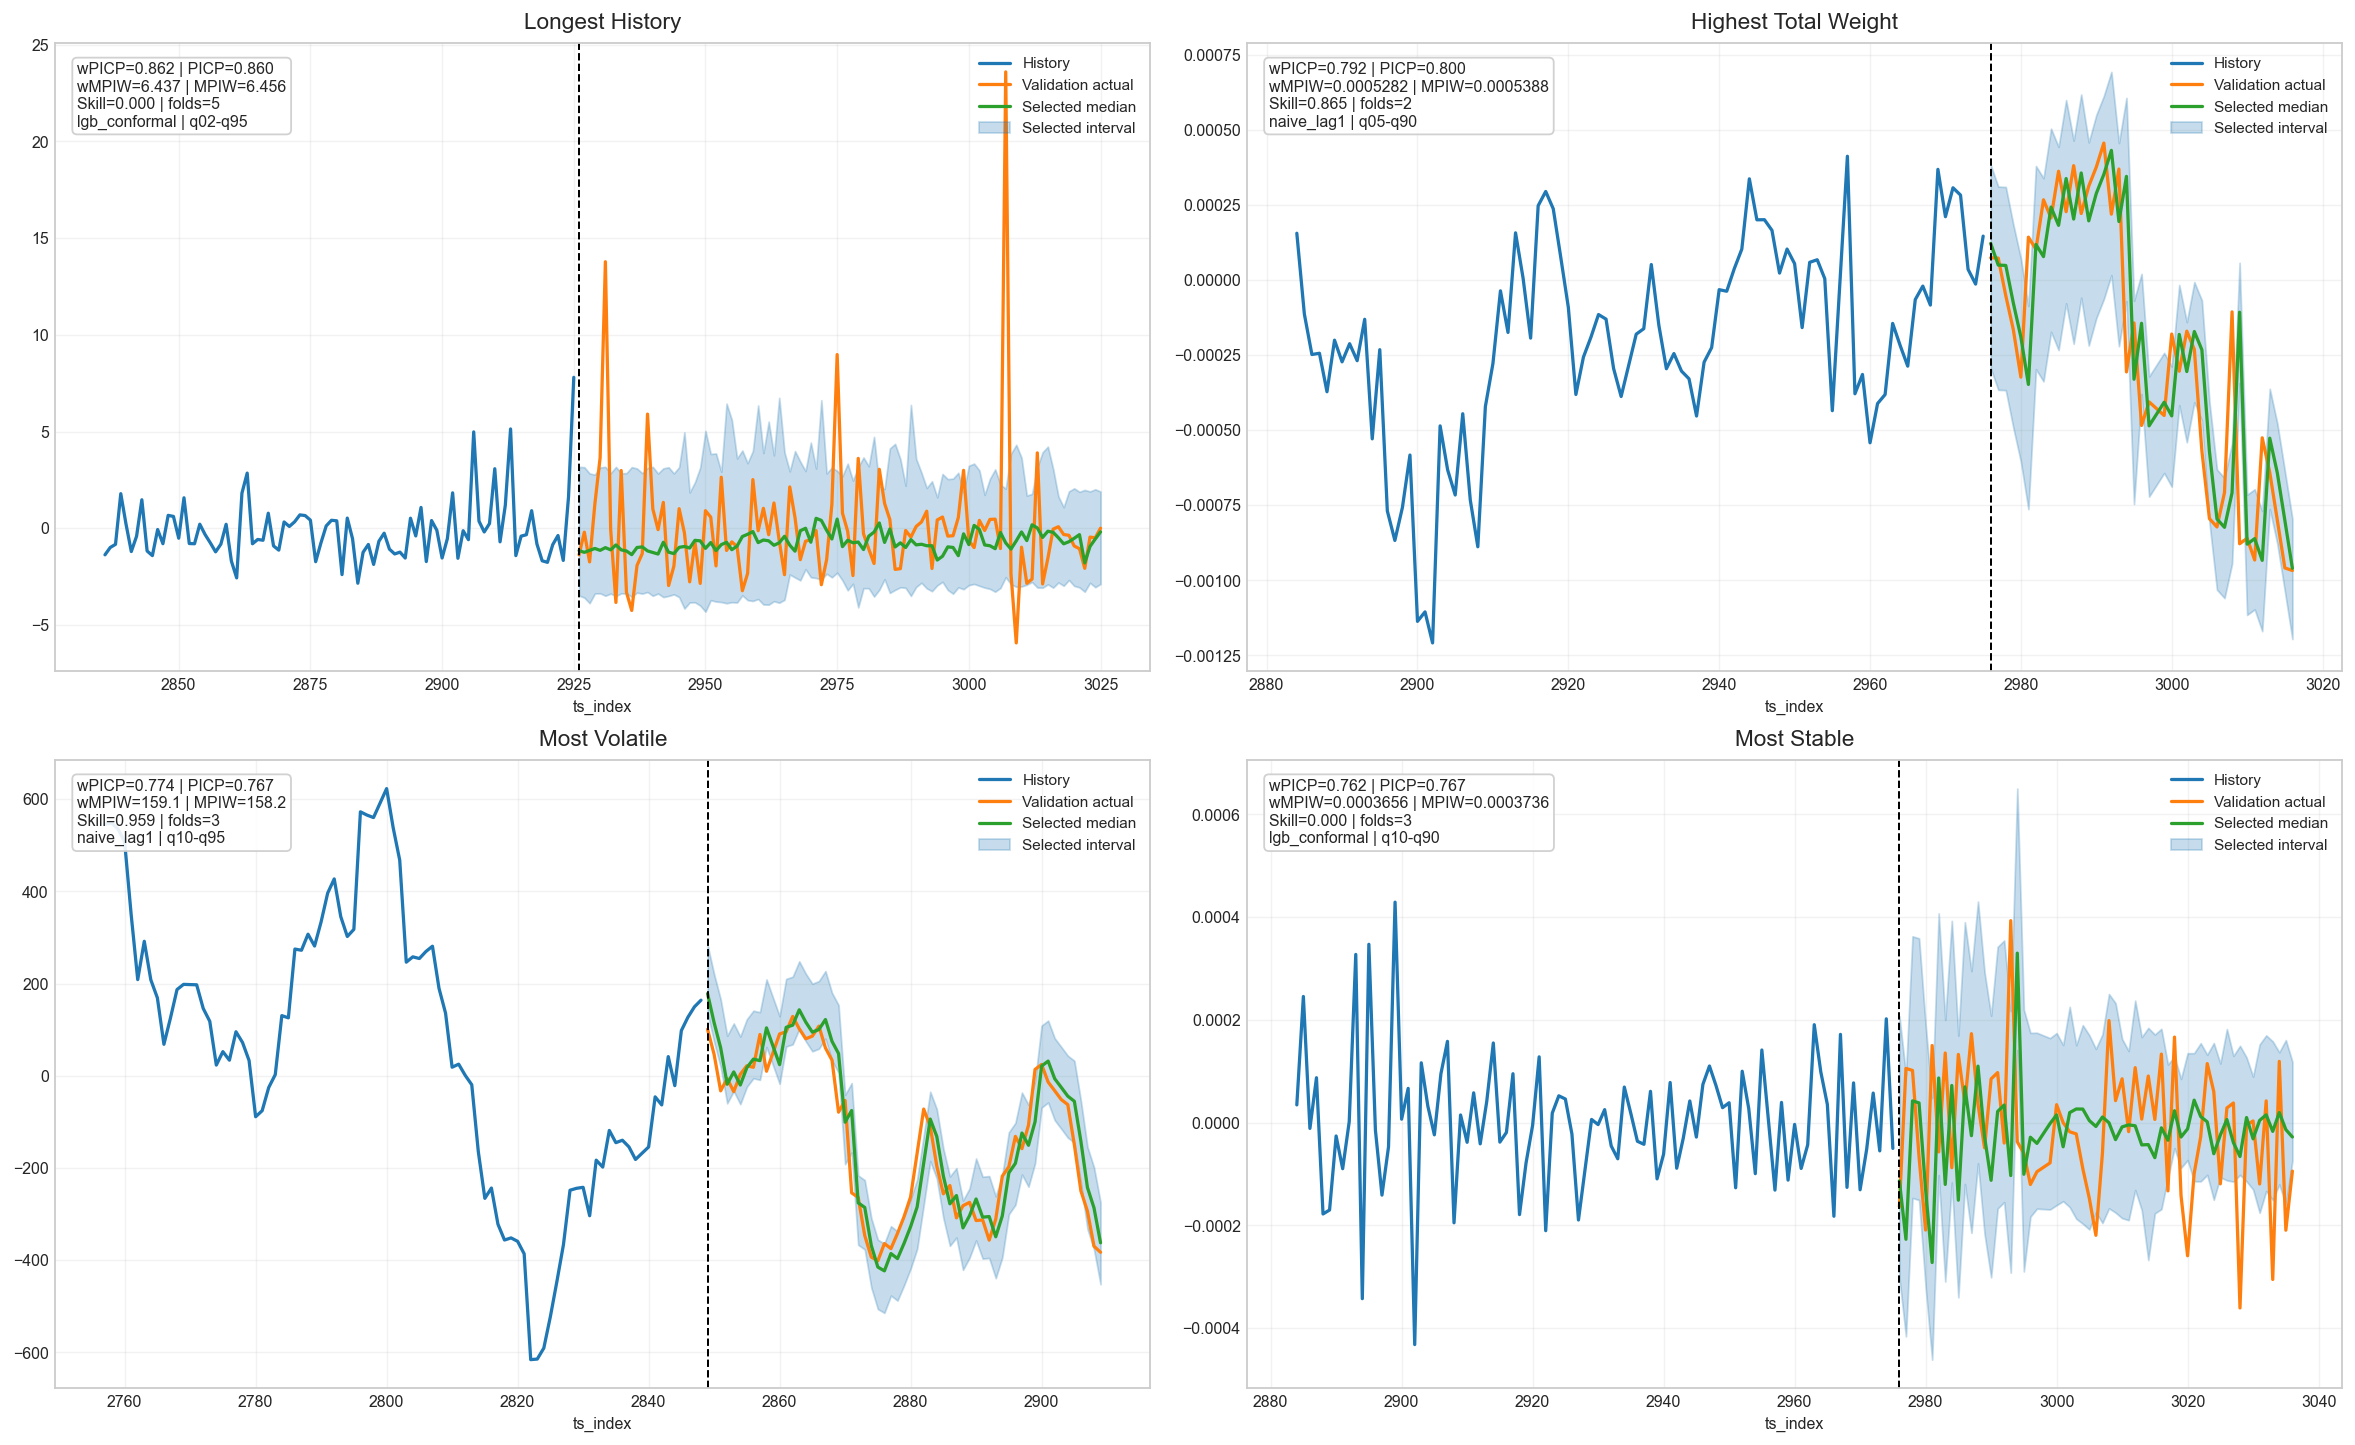

Saved: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/quantile_outputs/quantile_chosen_series_grid.png


In [5]:
def plot_filename(reason: str) -> str:
    return f"quantile_{reason.lower().replace(' ', '_')}_plot.png"


def draw_series_panel(
    ax,
    reason: str,
    *,
    title_size: float,
    stats_font: float,
    legend_font: float,
    tick_font: float,
    line_width: float,
) -> None:
    summary_row = summary_df.loc[summary_df["Series"] == reason].iloc[0]
    pred_group = prediction_df.loc[prediction_df["Series"] == reason].sort_values(TIME_COL).reset_index(drop=True)
    history_frame = prepared_series[reason]
    history_frame = history_frame.loc[history_frame[TIME_COL] < pred_group[TIME_COL].min()].copy()

    ax.set_facecolor("white")
    ax.plot(
        history_frame[TIME_COL],
        history_frame[TARGET_COL],
        label="History",
        color="tab:blue",
        linewidth=line_width,
    )
    ax.plot(
        pred_group[TIME_COL],
        pred_group[TARGET_COL],
        label="Validation actual",
        color="tab:orange",
        linewidth=line_width,
    )
    ax.plot(
        pred_group[TIME_COL],
        pred_group["pred_median"],
        label="Selected median",
        color="tab:green",
        linewidth=line_width,
    )
    ax.fill_between(
        pred_group[TIME_COL],
        pred_group["pred_lower"],
        pred_group["pred_upper"],
        alpha=0.25,
        color="tab:blue",
        label="Selected interval",
    )
    ax.axvline(pred_group[TIME_COL].min(), color="black", linestyle="--", linewidth=1.1)
    ax.set_title(reason, fontsize=title_size, pad=8)
    stats_text = (
        f"wPICP={summary_row['wPICP_80']:.3f} | PICP={summary_row['PICP_80']:.3f}\n"
        f"wMPIW={summary_row['wMPIW_80']:.4g} | MPIW={summary_row['MPIW_80']:.4g}\n"
        f"Skill={summary_row['Skill']:.3f} | folds={int(summary_row['fold_count'])}\n"
        f"{summary_row['dominant_method']} | {summary_row['dominant_interval_pair']}"
    )
    ax.text(
        0.02,
        0.97,
        stats_text,
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=stats_font,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "edgecolor": "#cccccc",
            "alpha": 0.90,
        },
    )
    ax.set_xlabel(TIME_COL, fontsize=tick_font)
    ax.tick_params(axis="both", labelsize=tick_font)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=legend_font, loc="upper right", frameon=False)


for reason in REASON_ORDER:
    single_fig, single_ax = plt.subplots(figsize=(10.8, 5.1), constrained_layout=True)
    draw_series_panel(
        single_ax,
        reason,
        title_size=15.0,
        stats_font=10.2,
        legend_font=10.0,
        tick_font=10.5,
        line_width=2.2,
    )
    single_path = OUTPUT_DIR / plot_filename(reason)
    single_fig.savefig(single_path, dpi=220, bbox_inches="tight")
    plt.close(single_fig)
    print("Saved:", single_path)

fig, axes = plt.subplots(2, 2, figsize=(18, 11), constrained_layout=True)
axes = axes.ravel()

for ax, reason in zip(axes, REASON_ORDER):
    draw_series_panel(
        ax,
        reason,
        title_size=12.5,
        stats_font=8.8,
        legend_font=8.5,
        tick_font=8.8,
        line_width=1.8,
    )

plot_path = OUTPUT_DIR / "quantile_chosen_series_grid.png"
fig.savefig(plot_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", plot_path)